<a href="https://colab.research.google.com/github/Manoj132005/AU_Workshop_hackathon/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
!pip install kaggle
import kagglehub
rohanrao_air_quality_data_in_india_path = kagglehub.dataset_download('rohanrao/air-quality-data-in-india')

print('Data source import complete.')


Using Colab cache for faster access to the 'air-quality-data-in-india' dataset.
Data source import complete.


In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/air-quality-data-in-india/stations.csv
/kaggle/input/air-quality-data-in-india/station_hour.csv
/kaggle/input/air-quality-data-in-india/city_day.csv
/kaggle/input/air-quality-data-in-india/city_hour.csv
/kaggle/input/air-quality-data-in-india/station_day.csv


In [8]:
!ls

sample_data


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [ ]:
#Load the Dataset

In [12]:
import os
df = pd.read_csv(os.path.join(rohanrao_air_quality_data_in_india_path, "city_day.csv"))

print("📌 Shape:", df.shape)
print("\n📌 First 5 rows:")
df.head()

📌 Shape: (29531, 16)

📌 First 5 rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
#Initial Exploration

In [13]:
print("=" * 50)
print("📋 Column Names:")
print(df.columns.tolist())

print("\n📋 Data Types:")
print(df.dtypes)

print("\n📋 Dataset Info:")
df.info()

📋 Column Names:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

📋 Data Types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx        

In [ ]:
#Check Missing Values

In [17]:
print("📌 Missing Values BEFORE cleaning:")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

before = len(df)
df = df.dropna(subset=['AQI'])
after  = len(df)
print(f"\n✅ Dropped {before - after} rows where AQI was missing")
print(f"   Rows remaining: {after}")

📌 Missing Values BEFORE cleaning:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Total missing cells: 88488

✅ Dropped 4681 rows where AQI was missing
   Rows remaining: 24850


In [17]:
#Fill missing pollutant values with MEDIAN
# Median is better than mean when outliers are present

In [19]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
                  'NH3', 'CO', 'SO2', 'O3', 'Benzene',
                  'Toluene', 'Xylene']

print("\n📌 Filling missing pollutants with median:")
for col in pollutant_cols:
    if col in df.columns:
        median_val = df[col].median()
        missing_count = df[col].isnull().sum()
        df[col] = df[col].fillna(median_val)
        print(f"   {col:<12} → {missing_count} values filled with median {median_val:.3f}")



📌 Filling missing pollutants with median:
   PM2.5        → 678 values filled with median 48.785
   PM10         → 7086 values filled with median 96.180
   NO           → 387 values filled with median 9.910
   NO2          → 391 values filled with median 22.100
   NOx          → 1857 values filled with median 23.680
   NH3          → 6536 values filled with median 16.310
   CO           → 445 values filled with median 0.930
   SO2          → 605 values filled with median 9.220
   O3           → 807 values filled with median 31.250
   Benzene      → 3535 values filled with median 1.290
   Toluene      → 5826 values filled with median 3.575
   Xylene       → 15372 values filled with median 1.420


/tmp/ipykernel_303/2388622940.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(median_val)


In [20]:
print("\n📌 Missing Values AFTER cleaning:")
print(df.isnull().sum())
print("✅ Missing value handling complete!")


📌 Missing Values AFTER cleaning:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64
✅ Missing value handling complete!


In [21]:
#Convert Date to Datetime
#df['Date'] = pd.to_datetime(df['Date'])

In [22]:
df['Date'] = pd.to_datetime(df['Date'])

print("✅ Date column converted to datetime")
print(f"   dtype      : {df['Date'].dtype}")
print(f"   Start Date : {df['Date'].min().date()}")
print(f"   End Date   : {df['Date'].max().date()}")
print(f"   Total Days : {(df['Date'].max() - df['Date'].min()).days}")



✅ Date column converted to datetime
   dtype      : datetime64[ns]
   Start Date : 2015-01-01
   End Date   : 2020-07-01
   Total Days : 2008


/tmp/ipykernel_303/3904808157.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
#Filter Cities

In [24]:
print("📌 All Cities in Dataset:")
print(df['City'].unique())
print(f"\nTotal unique cities: {df['City'].nunique()}")
print("\nRecords per city:")
print(df['City'].value_counts())
print("\n✅ Using all cities for better generalization")
print(f"   Final shape after preprocessing: {df.shape}")


📌 All Cities in Dataset:
['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']

Total unique cities: 26

Records per city:
City
Delhi                 1999
Bengaluru             1910
Lucknow               1893
Chennai               1884
Hyderabad             1880
Patna                 1459
Gurugram              1453
Ahmedabad             1334
Visakhapatnam         1171
Amritsar              1126
Jaipur                1094
Thiruvananthapuram    1052
Amaravati              841
Mumbai                 775
Jorapokhar             771
Kolkata                754
Brajrajnagar           713
Talcher                698
Guwahati               495
Coimbatore             344
Chandigarh             299
Bhopal                 278
Shillong               205
Koch

In [ ]:
# FEATURE ENGINEERING

In [ ]:
#Extract Season Feature

✅ Season feature created
         Date  month  season
28 2015-01-29      1  Winter
29 2015-01-30      1  Winter
30 2015-01-31      1  Winter
31 2015-02-01      2  Winter
32 2015-02-02      2  Winter
33 2015-02-03      2  Winter
34 2015-02-04      2  Winter
35 2015-02-05      2  Winter
36 2015-02-06      2  Winter
37 2015-02-07      2  Winter
38 2015-02-08      2  Winter
39 2015-02-09      2  Winter


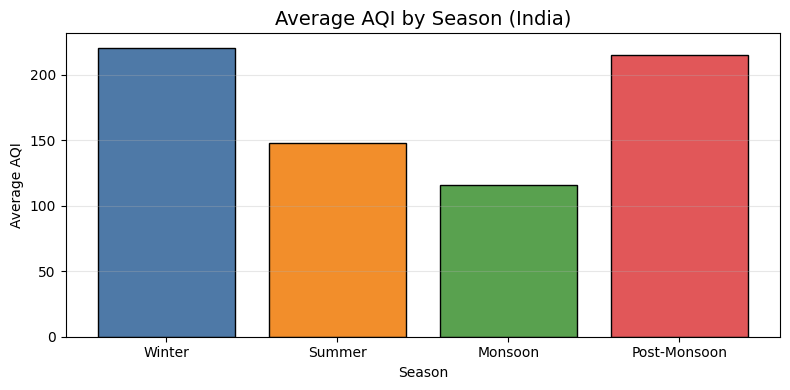


📌 Season-wise AQI summary:
               count   mean    std   min    25%    50%    75%     max
season                                                               
Monsoon      7713.00 115.56  96.60 14.00  64.00  89.00 124.00 1842.00
Post-Monsoon 3825.00 215.47 176.87 13.00  98.00 154.00 307.00 1747.00
Summer       7069.00 147.67 116.47 14.00  80.00 115.00 174.00 1459.00
Winter       6243.00 220.61 157.30 26.00 112.00 171.00 312.00 2049.00


In [26]:
def get_season(month):
    if month in [12, 1, 2]:       return 'Winter'      # 0
    elif month in [3, 4, 5]:      return 'Summer'      # 1
    elif month in [6, 7, 8, 9]:   return 'Monsoon'     # 2
    else:                          return 'Post-Monsoon' # 3

df['month'] = df['Date'].dt.month # Add this line to extract month
df['season'] = df['month'].apply(get_season)

print("✅ Season feature created")
print(df[['Date', 'month', 'season']].head(12))

# Season → numeric encoding for ML models
season_map = {'Winter': 0, 'Summer': 1, 'Monsoon': 2, 'Post-Monsoon': 3}
df['season_enc'] = df['season'].map(season_map)

# Visualise — AQI by Season
plt.figure(figsize=(8, 4))
season_aqi = df.groupby('season')['AQI'].mean().reindex(
    ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
plt.bar(season_aqi.index, season_aqi.values, color=colors, edgecolor='black')
plt.title("Average AQI by Season (India)", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Average AQI")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📌 Season-wise AQI summary:")
print(df.groupby('season')['AQI'].describe().round(2))

In [ ]:
#Extract Month Feature

✅ Month feature created
         Date  month
28 2015-01-29      1
29 2015-01-30      1
30 2015-01-31      1
31 2015-02-01      2
32 2015-02-02      2
33 2015-02-03      2
34 2015-02-04      2
35 2015-02-05      2
36 2015-02-06      2
37 2015-02-07      2


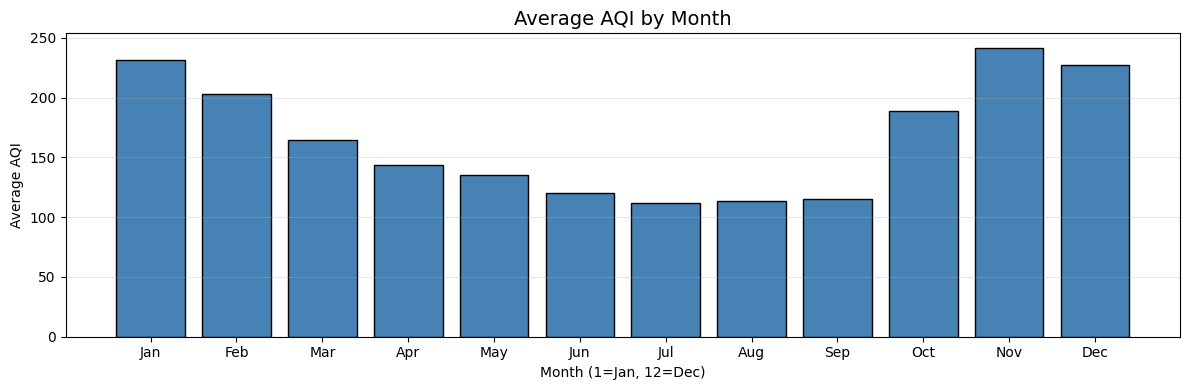

In [27]:
df['month'] = df['Date'].dt.month

print("✅ Month feature created")
print(df[['Date', 'month']].head(10))

# Quick visualisation — AQI by Month
plt.figure(figsize=(12, 4))
monthly_aqi = df.groupby('month')['AQI'].mean()
plt.bar(monthly_aqi.index, monthly_aqi.values, color='steelblue', edgecolor='black')
plt.title("Average AQI by Month", fontsize=14)
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Average AQI")
plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
#Extract Day of Week Feature

✅ Day of week feature created
         Date  day_of_week
28 2015-01-29            3
29 2015-01-30            4
30 2015-01-31            5
31 2015-02-01            6
32 2015-02-02            0
33 2015-02-03            1
34 2015-02-04            2
35 2015-02-05            3
36 2015-02-06            4
37 2015-02-07            5


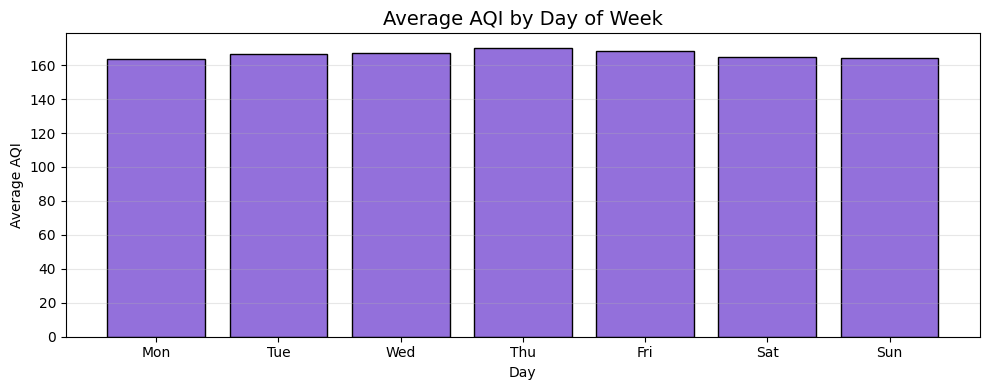

In [28]:
df['day_of_week'] = df['Date'].dt.dayofweek
# 0 = Monday ... 6 = Sunday

print("✅ Day of week feature created")
print(df[['Date', 'day_of_week']].head(10))

# Visualise — AQI by Day of Week
plt.figure(figsize=(10, 4))
day_aqi = df.groupby('day_of_week')['AQI'].mean()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.bar(day_labels, day_aqi.values, color='mediumpurple', edgecolor='black')
plt.title("Average AQI by Day of Week", fontsize=14)
plt.xlabel("Day")
plt.ylabel("Average AQI")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
df['year'] = df['Date'].dt.year

# City Encoding — convert city name to number for ML
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['City_enc'] = le.fit_transform(df['City'])

print("✅ Additional features created:")
print(f"   year        → {df['year'].unique()}")
print(f"   City_enc    → 0 to {df['City_enc'].max()} ({df['City'].nunique()} cities)")



✅ Additional features created:
   year        → [2015 2016 2017 2018 2019 2020]
   City_enc    → 0 to 25 (26 cities)


In [ ]:
#Final Feature Summary

In [30]:
print("\n" + "=" * 55)
print("✅ ALL FEATURES READY")
print("=" * 55)

engineered_features = ['month', 'season', 'season_enc',
                       'day_of_week', 'year', 'City_enc']

print("\n📌 Engineered Features:")
print(df[engineered_features].head(10))

print("\n📌 Complete Feature List for ML Model:")
feature_cols = [c for c in pollutant_cols if c in df.columns] + \
               ['month', 'day_of_week', 'year', 'season_enc', 'City_enc']
print(feature_cols)

print(f"\n📌 Final Dataset Shape : {df.shape}")
print(f"📌 Total Features      : {len(feature_cols)}")
print(f"📌 Target Column       : AQI")
print(f"📌 Missing Values      : {df.isnull().sum().sum()}")

# Save for next step
df.to_csv("aqi_featured.csv", index=False)
print("\n💾 Saved as: aqi_featured.csv")
print("🚀 Ready for Step 3: EDA & Model Building!")


✅ ALL FEATURES READY

📌 Engineered Features:
    month  season  season_enc  day_of_week  year  City_enc
28      1  Winter           0            3  2015         0
29      1  Winter           0            4  2015         0
30      1  Winter           0            5  2015         0
31      2  Winter           0            6  2015         0
32      2  Winter           0            0  2015         0
33      2  Winter           0            1  2015         0
34      2  Winter           0            2  2015         0
35      2  Winter           0            3  2015         0
36      2  Winter           0            4  2015         0
37      2  Winter           0            5  2015         0

📌 Complete Feature List for ML Model:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'month', 'day_of_week', 'year', 'season_enc', 'City_enc']

📌 Final Dataset Shape : (24850, 22)
📌 Total Features      : 17
📌 Target Column       : AQI
📌 Missing Values    

In [ ]:
# Exploratory Data Analysis

In [ ]:
#importing libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']   = 11


In [33]:
# Load Cleaned Dataset

In [34]:
df = pd.read_csv("aqi_featured.csv")
df['Date'] = pd.to_datetime(df['Date'])

print("📌 Shape      :", df.shape)
print("📌 Columns    :", df.columns.tolist())
print("📌 AQI range  :", df['AQI'].min(), "→", df['AQI'].max())
df.head()

📌 Shape      : (24850, 22)
📌 Columns    : ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'month', 'season', 'season_enc', 'day_of_week', 'year', 'City_enc']
📌 AQI range  : 13.0 → 2049.0


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,month,season,season_enc,day_of_week,year,City_enc
0,Ahmedabad,2015-01-29,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,3.14,209.00,Poor,1,Winter,0,3,2015,0
1,Ahmedabad,2015-01-30,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,4.81,328.00,Very Poor,1,Winter,0,4,2015,0
2,Ahmedabad,2015-01-31,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,7.67,514.00,Severe,1,Winter,0,5,2015,0
3,Ahmedabad,2015-02-01,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,25.87,782.00,Severe,2,Winter,0,6,2015,0
4,Ahmedabad,2015-02-02,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,35.61,914.00,Severe,2,Winter,0,0,2015,0


In [35]:
#EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:

# Histogram with KDE

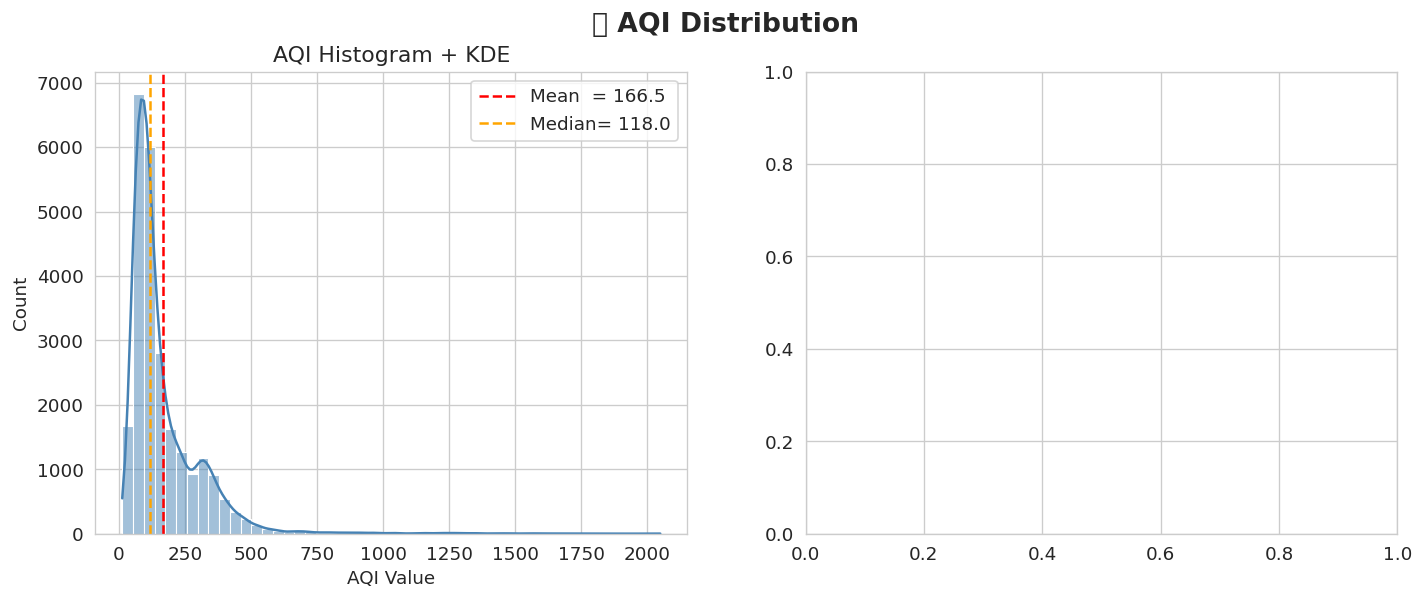

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📊 AQI Distribution", fontsize=16, fontweight='bold')

sns.histplot(df['AQI'], bins=50, kde=True,
             color='steelblue', ax=axes[0])
axes[0].axvline(df['AQI'].mean(),   color='red',    linestyle='--', label=f"Mean  = {df['AQI'].mean():.1f}")
axes[0].axvline(df['AQI'].median(), color='orange', linestyle='--', label=f"Median= {df['AQI'].median():.1f}")
axes[0].set_title("AQI Histogram + KDE")
axes[0].set_xlabel("AQI Value")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot

In [37]:
sns.boxplot(y=df['AQI'], color='lightcoral', ax=axes[1])
axes[1].set_title("AQI Boxplot (Outlier View)")
axes[1].set_ylabel("AQI Value")

plt.tight_layout()
plt.show()

<Figure size 768x576 with 0 Axes>

AQI Category breakdown

In [ ]:

# Pie chart of categories


📌 AQI Category Breakdown:
AQI_Category
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe           795
Name: count, dtype: int64


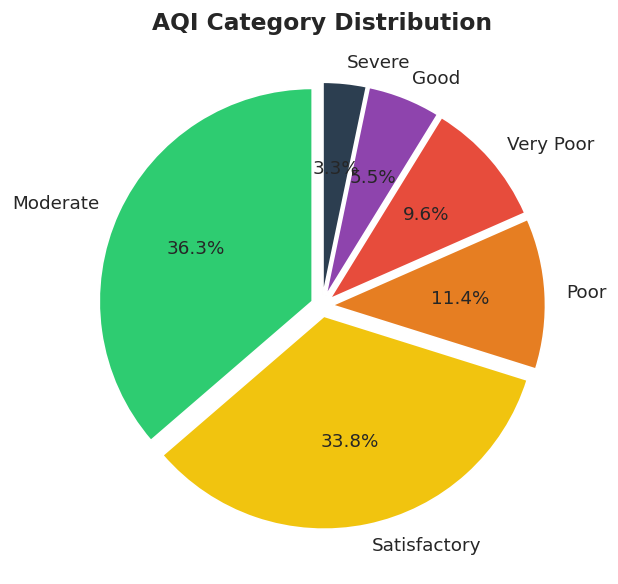

In [38]:
print("\n📌 AQI Category Breakdown:")
bins   = [0, 50, 100, 200, 300, 400, 500]
labels = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
df['AQI_Category'] = pd.cut(df['AQI'], bins=bins, labels=labels)
print(df['AQI_Category'].value_counts())

plt.figure(figsize=(8, 5))
df['AQI_Category'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#2c3e50'],
    startangle=90, explode=[0.05]*6
)
plt.title("AQI Category Distribution", fontsize=14, fontweight='bold')
plt.ylabel("")
plt.tight_layout()
plt.show()

Correlation Heatmap

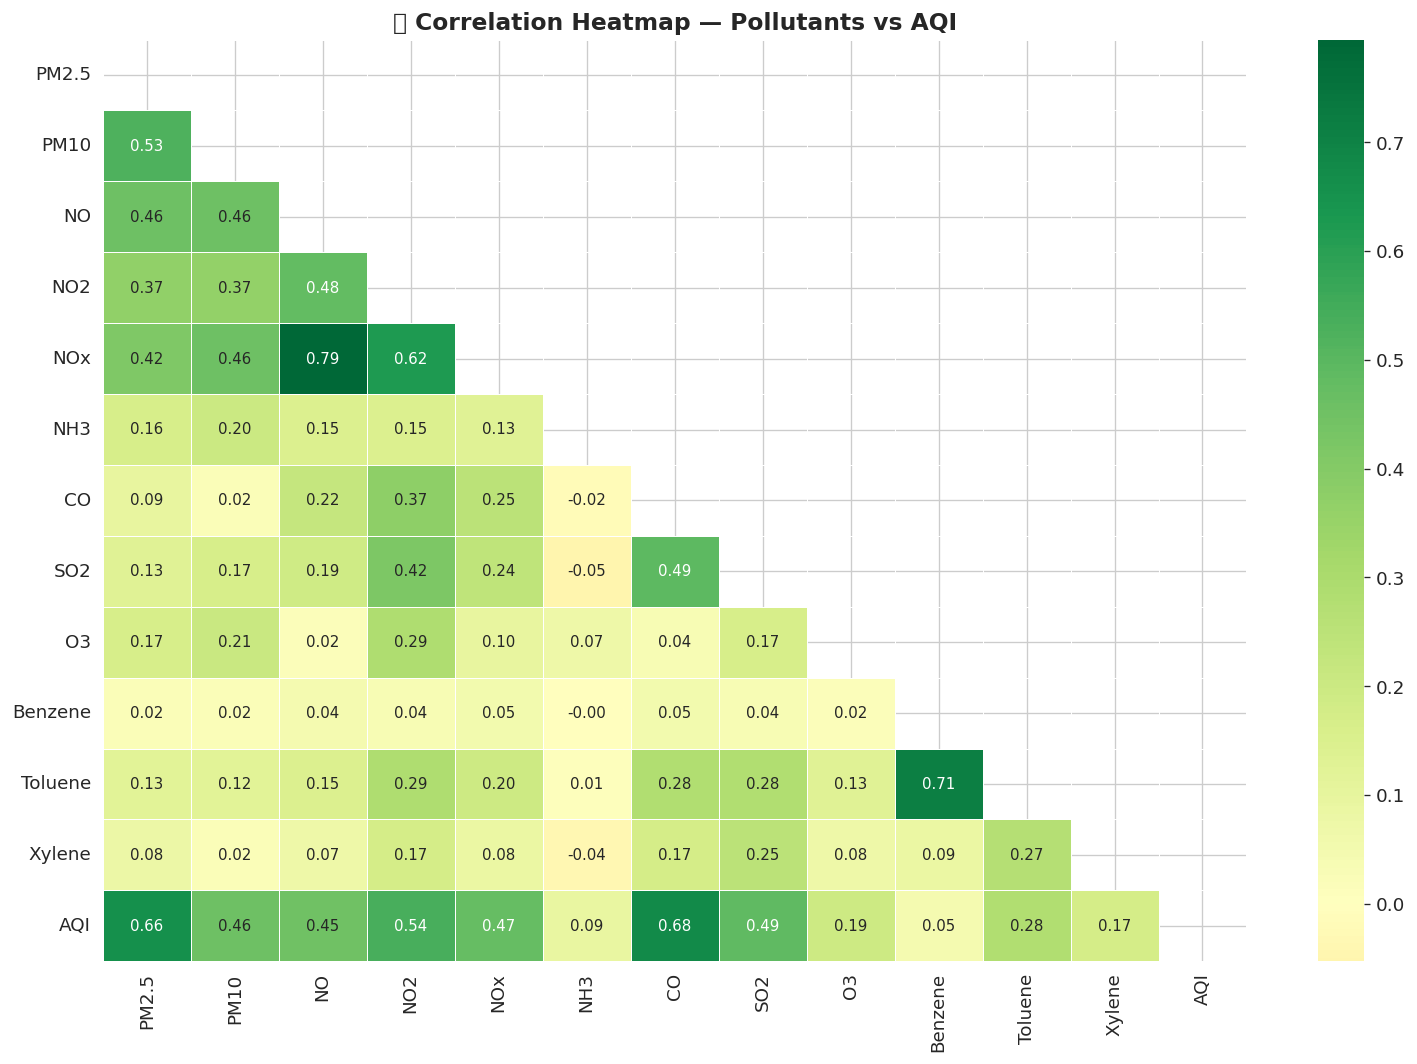

In [39]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
                  'NH3', 'CO', 'SO2', 'O3', 'Benzene',
                  'Toluene', 'Xylene', 'AQI']

corr_cols = [c for c in pollutant_cols if c in df.columns]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            annot_kws={"size": 9})
plt.title("🔥 Correlation Heatmap — Pollutants vs AQI",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
print("\n📌 Top Features Correlated with AQI:")
aqi_corr = corr_matrix['AQI'].drop('AQI').sort_values(ascending=False)
print(aqi_corr)


📌 Top Features Correlated with AQI:
CO        0.68
PM2.5     0.66
NO2       0.54
SO2       0.49
NOx       0.47
PM10      0.46
NO        0.45
Toluene   0.28
O3        0.19
Xylene    0.17
NH3       0.09
Benzene   0.05
Name: AQI, dtype: float64


Pollution Trend Over Time


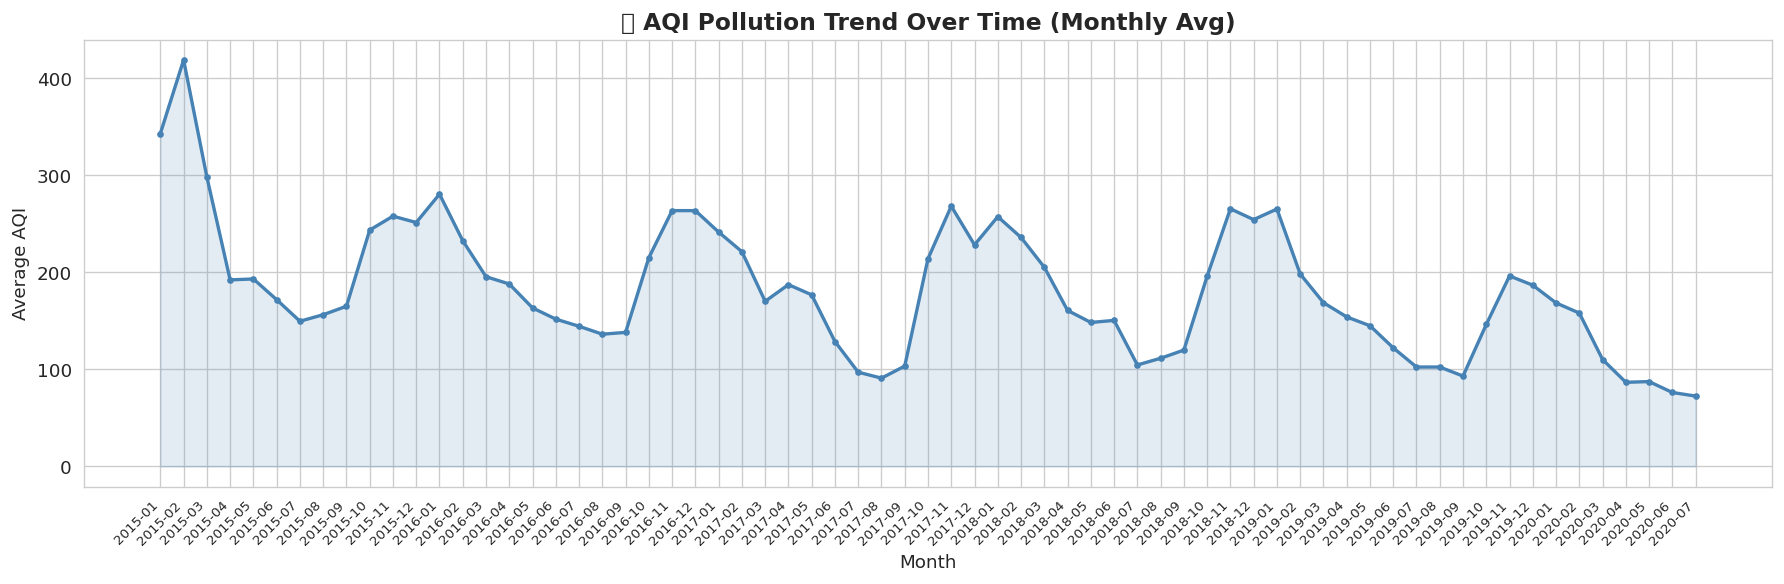

In [41]:
monthly_aqi = df.groupby(df['Date'].dt.to_period('M'))['AQI'].mean()

plt.figure(figsize=(15, 5))
plt.plot(monthly_aqi.index.astype(str), monthly_aqi.values,
         color='steelblue', linewidth=2, marker='o', markersize=3)
plt.fill_between(range(len(monthly_aqi)), monthly_aqi.values,
                 alpha=0.15, color='steelblue')
plt.title("📈 AQI Pollution Trend Over Time (Monthly Avg)",
          fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

AQI by City — Top 10 Most Polluted

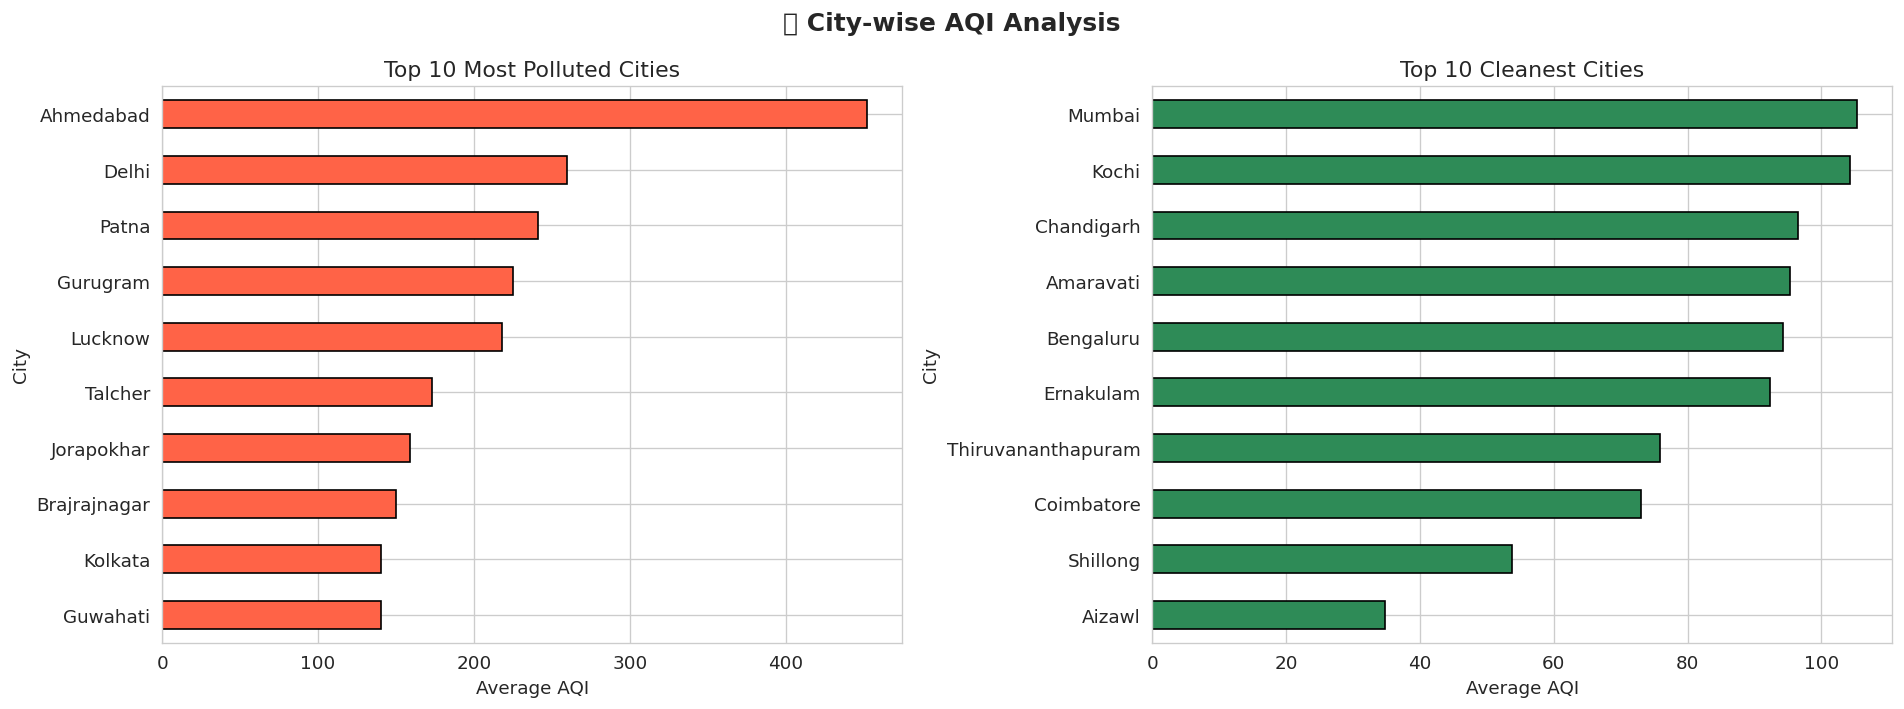

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("🏙️ City-wise AQI Analysis", fontsize=15, fontweight='bold')

city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

# Top 10 most polluted
city_aqi.head(10).plot(kind='barh', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title("Top 10 Most Polluted Cities")
axes[0].set_xlabel("Average AQI")
axes[0].invert_yaxis()

# Top 10 cleanest
city_aqi.tail(10).plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title("Top 10 Cleanest Cities")
axes[1].set_xlabel("Average AQI")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

AQI by Season & Month

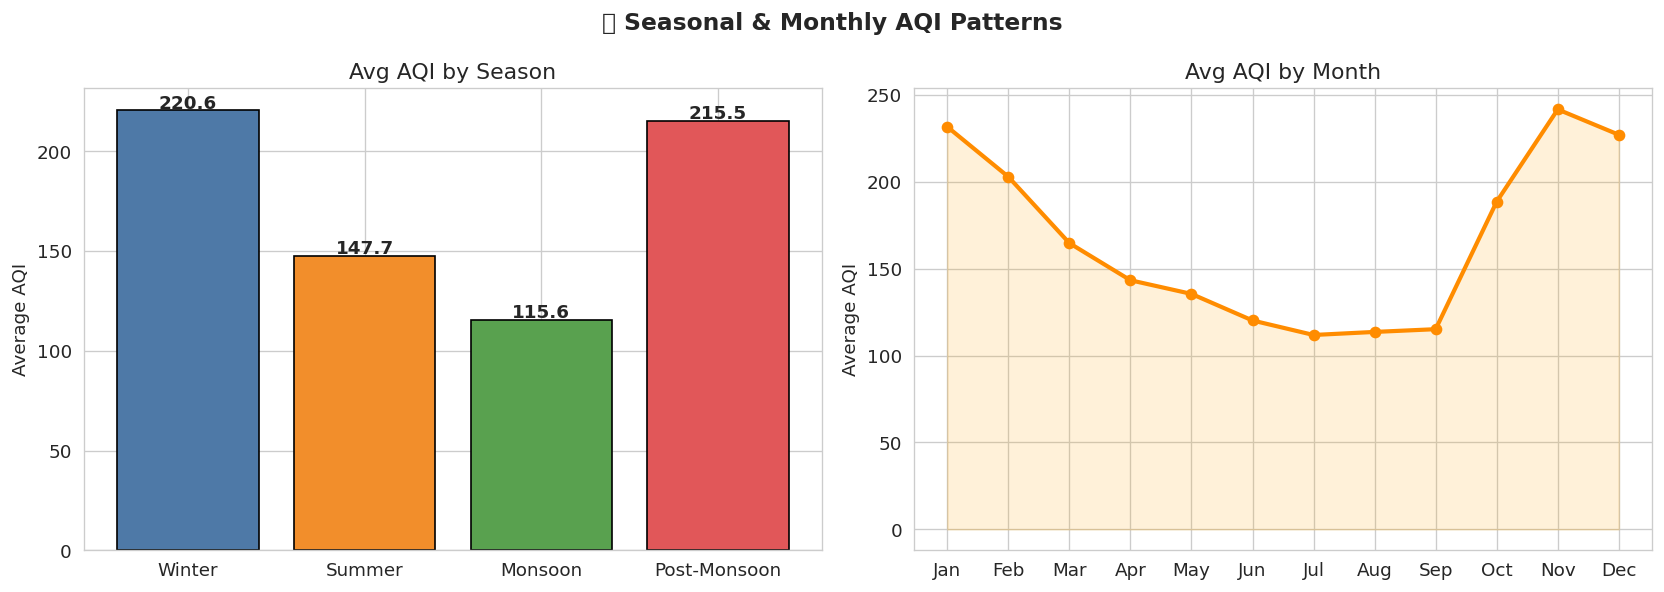

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("🌦️ Seasonal & Monthly AQI Patterns", fontsize=14, fontweight='bold')

# By Season
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_aqi   = df.groupby('season')['AQI'].mean().reindex(season_order)
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
axes[0].bar(season_aqi.index, season_aqi.values, color=colors, edgecolor='black')
axes[0].set_title("Avg AQI by Season")
axes[0].set_ylabel("Average AQI")
for i, v in enumerate(season_aqi.values):
    axes[0].text(i, v + 1, f"{v:.1f}", ha='center', fontweight='bold')

# By Month
month_aqi    = df.groupby('month')['AQI'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].plot(month_labels, month_aqi.values,
             marker='o', color='darkorange', linewidth=2.5)
axes[1].fill_between(range(12), month_aqi.values, alpha=0.15, color='orange')
axes[1].set_title("Avg AQI by Month")
axes[1].set_ylabel("Average AQI")
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_labels)

plt.tight_layout()
plt.show()

MACHINE LEARNING MODELS


In [ ]:
# Prepare Features & Target

In [49]:
feature_cols = [c for c in ['PM2.5','PM10','NO','NO2','NOx',
                             'NH3','CO','SO2','O3','Benzene',
                             'Toluene','Xylene']
                if c in df.columns] + \
               ['month', 'day_of_week', 'year', 'season_enc', 'City_enc']

X = df[feature_cols]
y = df['AQI']

# Train-Test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("📌 Features used :", feature_cols)
print(f"\n📌 Train size    : {X_train.shape}")
print(f"📌 Test size     : {X_test.shape}")
print(f"📌 Target (AQI)  : {y.shape}")

📌 Features used : ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'month', 'day_of_week', 'year', 'season_enc', 'City_enc']

📌 Train size    : (19880, 17)
📌 Test size     : (4970, 17)
📌 Target (AQI)  : (24850,)


In [ ]:
#Evaluation Helper Function

In [51]:

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model and print RMSE, MAE, R² metrics"""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    r2   = r2_score(y_te, preds)

    print(f"\n{'='*45}")
    print(f"  🤖 {name}")
    print(f"{'='*45}")
    print(f"  RMSE  : {rmse:.4f}   ← lower is better")
    print(f"  MAE   : {mae:.4f}   ← lower is better")
    print(f"  R²    : {r2:.4f}   ← closer to 1 is better")

    return {
        "Model": name,
        "RMSE" : round(rmse, 4),
        "MAE"  : round(mae,  4),
        "R²"   : round(r2,   4)
    }, model, preds

results  = []
models   = {}
all_preds= {}

Models

In [ ]:
#Model 1 — Linear Regression

In [52]:
print("🔵 Training Linear Regression...")
r, m, p = evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train, y_train, X_test, y_test
)
results.append(r)
models["Linear Regression"]   = m
all_preds["Linear Regression"] = p

🔵 Training Linear Regression...

  🤖 Linear Regression
  RMSE  : 59.2601   ← lower is better
  MAE   : 30.9807   ← lower is better
  R²    : 0.8082   ← closer to 1 is better


In [53]:
#Model 2 — Random Forest Regressor

In [54]:
print("🟢 Training Random Forest Regressor...")
r, m, p = evaluate_model(
    "Random Forest",
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)
results.append(r)
models["Random Forest"]   = m
all_preds["Random Forest"] = p

🟢 Training Random Forest Regressor...

  🤖 Random Forest
  RMSE  : 40.7837   ← lower is better
  MAE   : 20.5621   ← lower is better
  R²    : 0.9092   ← closer to 1 is better


In [55]:
#Model 3 — Gradient Boosting

In [56]:
print("🟠 Training Gradient Boosting Regressor...")
r, m, p = evaluate_model(
    "Gradient Boosting",
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                               max_depth=4, random_state=42),
    X_train, y_train, X_test, y_test
)
results.append(r)
models["Gradient Boosting"]   = m
all_preds["Gradient Boosting"] = p


🟠 Training Gradient Boosting Regressor...

  🤖 Gradient Boosting
  RMSE  : 42.2783   ← lower is better
  MAE   : 22.2473   ← lower is better
  R²    : 0.9024   ← closer to 1 is better


In [ ]:
# Model 4 — XGBoost

In [57]:
print("🔴 Training XGBoost Regressor...")
r, m, p = evaluate_model(
    "XGBoost",
    XGBRegressor(n_estimators=100, learning_rate=0.1,
                 max_depth=4, random_state=42, verbosity=0),
    X_train, y_train, X_test, y_test
)
results.append(r)
models["XGBoost"]   = m
all_preds["XGBoost"] = p

🔴 Training XGBoost Regressor...

  🤖 XGBoost
  RMSE  : 42.7781   ← lower is better
  MAE   : 22.0739   ← lower is better
  R²    : 0.9001   ← closer to 1 is better


In [58]:
#Model Comparison Table

In [59]:
results_df = pd.DataFrame(results)

print("\n\n" + "="*55)
print("📊  MODEL COMPARISON SUMMARY")
print("="*55)
print(results_df.to_string(index=False))

best_model = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"\n🏆 Best Model : {best_model}")
print("="*55)



📊  MODEL COMPARISON SUMMARY
            Model  RMSE   MAE   R²
Linear Regression 59.26 30.98 0.81
    Random Forest 40.78 20.56 0.91
Gradient Boosting 42.28 22.25 0.90
          XGBoost 42.78 22.07 0.90

🏆 Best Model : Random Forest


In [ ]:
# Model Comparison — Bar Charts

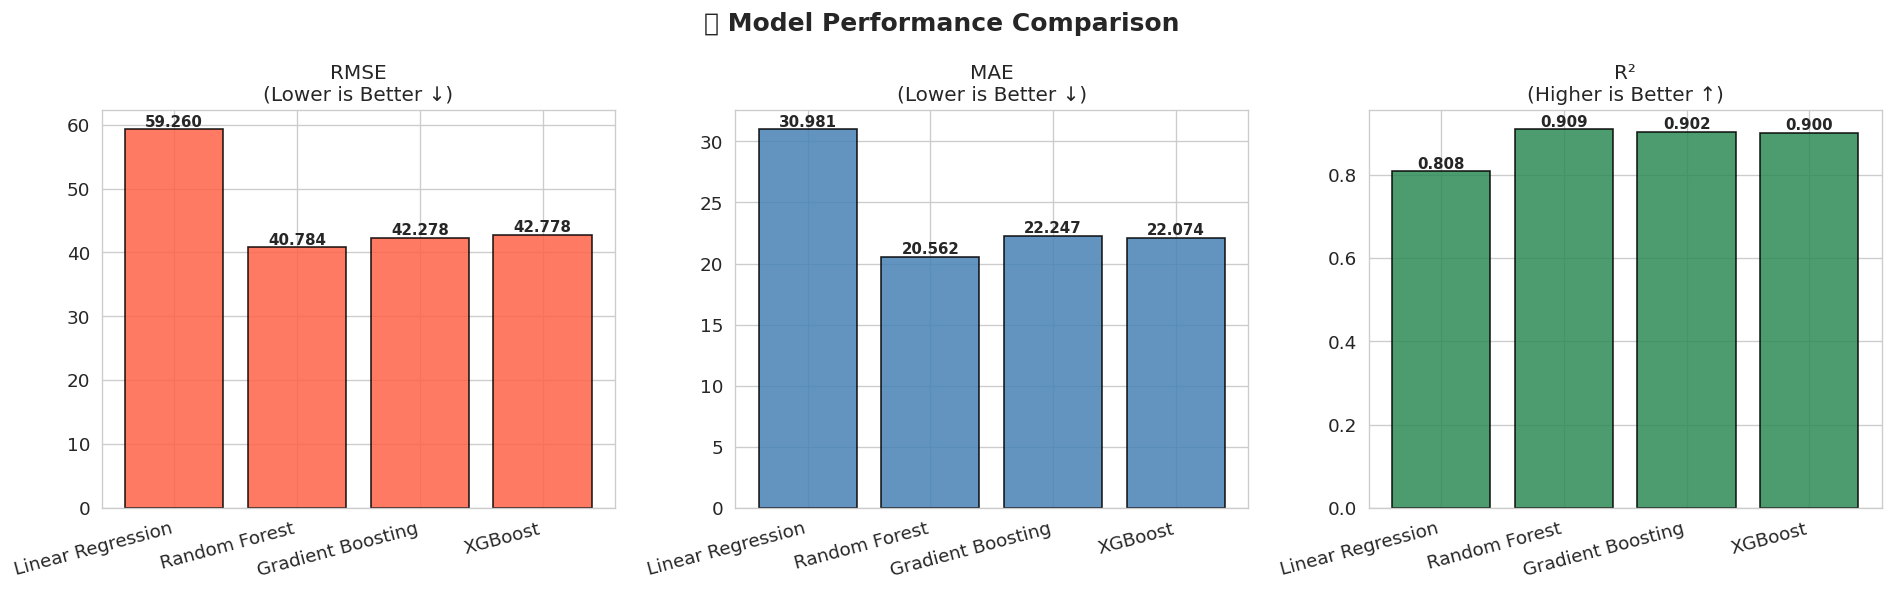

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("📊 Model Performance Comparison", fontsize=15, fontweight='bold')

metrics = ["RMSE", "MAE", "R²"]
colors  = ["tomato", "steelblue", "seagreen"]
notes   = ["Lower is Better ↓", "Lower is Better ↓", "Higher is Better ↑"]

for ax, metric, color, note in zip(axes, metrics, colors, notes):
    bars = ax.bar(results_df["Model"], results_df[metric],
                  color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f"{metric}\n({note})", fontsize=12)
    ax.set_xticklabels(results_df["Model"], rotation=15, ha='right')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [61]:
#Actual vs Predicted Plot (Best Model)

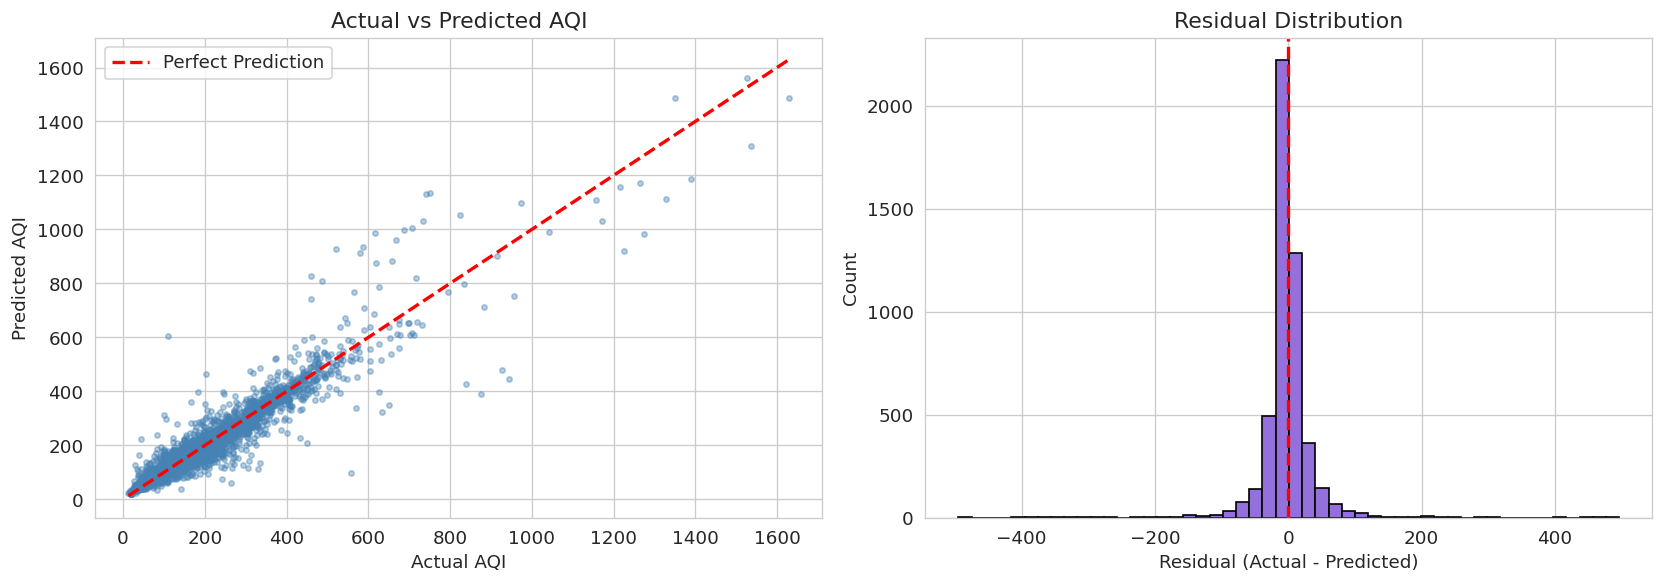

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_preds = all_preds[best_model]

axes[0].scatter(y_test, best_preds, alpha=0.4, color='steelblue', s=10)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel("Actual AQI")
axes[0].set_ylabel("Predicted AQI")
axes[0].set_title("Actual vs Predicted AQI")
axes[0].legend()

# Residuals (Errors)
residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=50, color='mediumpurple', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

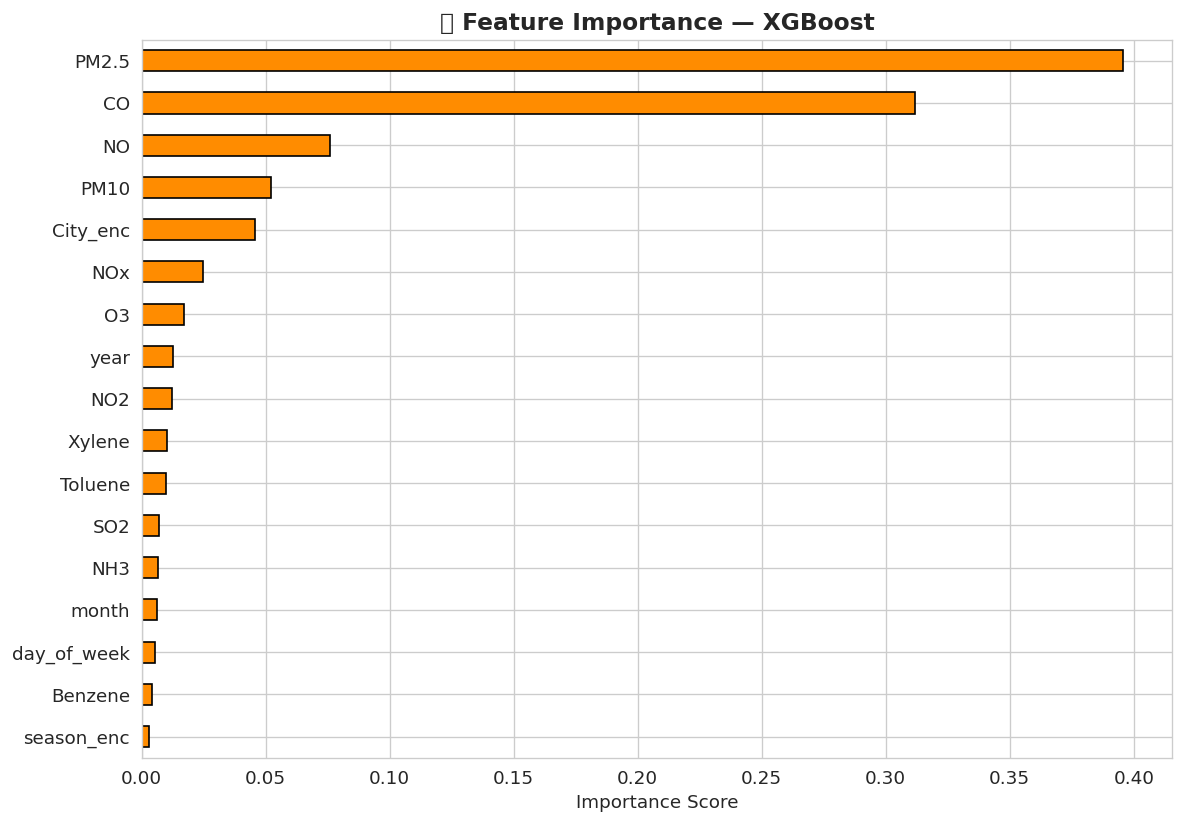


📌 Top 5 Most Important Features:
PM2.5      0.40
CO         0.31
NO         0.08
PM10       0.05
City_enc   0.05
dtype: float32


In [67]:
xgb_model = models["XGBoost"]
importances = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title("🔍 Feature Importance — XGBoost", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\n📌 Top 5 Most Important Features:")
print(importances.sort_values(ascending=False).head(5))

In [ ]:
#Final model selected

In [65]:
print("\n" + "="*55)
print("✅  PROJECT COMPLETE — FINAL SUMMARY")
print("="*55)
print(f"  Dataset shape       : {df.shape}")
print(f"  Features used       : {len(feature_cols)}")
print(f"  Models trained      : 4")
print(f"  Best Model          : {best_model}")
best_row = results_df[results_df['Model'] == best_model].iloc[0]
print(f"  Best RMSE           : {best_row['RMSE']}")
print(f"  Best MAE            : {best_row['MAE']}")
print(f"  Best R²             : {best_row['R²']}")
print("="*55)
print("\n🚀 Next Steps:")
print("   → Step 5: Hyperparameter Tuning (GridSearchCV)")
print("   → Step 6: City-wise models for higher accuracy")
print("   → Step 7: Deploy with Streamlit Dashboard")



✅  PROJECT COMPLETE — FINAL SUMMARY
  Dataset shape       : (24850, 23)
  Features used       : 17
  Models trained      : 4
  Best Model          : Random Forest
  Best RMSE           : 40.7837
  Best MAE            : 20.5621
  Best R²             : 0.9092

🚀 Next Steps:
   → Step 5: Hyperparameter Tuning (GridSearchCV)
   → Step 6: City-wise models for higher accuracy
   → Step 7: Deploy with Streamlit Dashboard


In [71]:
import pickle
from google.colab import files
import os

# Save the best model (Random Forest) first, as it was not explicitly saved before
best_trained_model = models[best_model]
model_filename = "best_rf_aqi_model.pkl"

with open(model_filename, 'wb') as file:
    pickle.dump(best_trained_model, file)
print(f"✅ Best model '{best_model}' saved as {model_filename}")

# \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n# CELL 1: Download model directly from Colab to your PC
# \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500

# Check if model file exists before downloading
if os.path.exists(model_filename):
    files.download(model_filename)
    print(f"✅ Model downloaded: {model_filename}")
else:
    print("❌ Model file not found!")
    print("   Make sure the model was saved correctly in this notebook.")


# \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\n# CELL 2: (Optional) Verify model before downloading
# \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
import numpy as np

# Load and test model
with open(model_filename, "rb") as f:
    loaded_model = pickle.load(f)

print("✅ Model loaded successfully!")
print(f"   Model type   : {type(loaded_model)}")
print(f"   Features     : {loaded_model.n_features_in_}")
print(f"   Estimators   : {loaded_model.n_estimators}")
print(f"   Best Params  : {loaded_model.get_params()}")

✅ Best model 'Random Forest' saved as best_rf_aqi_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded: best_rf_aqi_model.pkl
✅ Model loaded successfully!
   Model type   : <class 'sklearn.ensemble._forest.RandomForestRegressor'>
   Features     : 17
   Estimators   : 100
   Best Params  : {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
